# FarmTech Solutions — Visão Computacional com YOLOv5 (Fase 6 · Entrega 1)

**Cenário:** a FarmTech apresenta a um cliente do agronegócio um detector de **animais peçonhentos** para a segurança dos trabalhadores rurais e do rebanho: câmeras em galpões, currais e áreas de colheita reconhecem **cobras** e **aranhas** e podem disparar alertas antes de um acidente.

| Classe | Objeto | Motivo da escolha |
|---|---|---|
| 0 | `cobra` | corpo alongado e contínuo, sem patas, padrão de escamas |
| 1 | `aranha` | corpo compacto com oito patas finas e articuladas, muitas vezes sobre teia |

As duas classes são visualmente **bem diferentes** (silhueta linear × radial), como pede o enunciado. Nenhuma das duas existe no COCO, o dataset de pré-treino do YOLO — o modelo precisa aprendê-las de fato.

**Roteiro do notebook**

1. Preparação do ambiente (Google Drive + YOLOv5)
2. Montagem do dataset (200 + 200 imagens, divididas 160/20/20) no Google Drive
3. Rotulação (caixas do Open Images + pacote para o Make Sense AI)
4. Treinamento — duas simulações: **30** e **60 épocas**
5. Validação — métricas e curvas de aprendizado
6. Teste — métricas no conjunto de teste e imagens processadas (`runs/detect/expX`)
7. Comparação entre as simulações e conclusões

## 1. Preparação do ambiente

> Execute em **Ambiente de execução → Alterar tipo → GPU (T4)**. Todos os artefatos (dataset, rótulos, pesos e resultados) ficam no Google Drive, em `MyDrive/FarmTech_Fase6`.

In [1]:
# Conecta o Colab ao Google Drive pessoal/do grupo
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Exibe os gráficos na saída do notebook
%matplotlib inline
import os, json, time, glob, shutil, random   # utilitários de sistema e arquivos
from pathlib import Path                       # manipulação de caminhos

# ---- Configuração central do projeto -------------------------------------
DRIVE_ROOT = Path('/content/drive/MyDrive/FarmTech_Fase6')  # pasta do projeto no Drive
DATASET    = DRIVE_ROOT / 'dataset'          # train/ val/ test/ (images + labels)
MAKESENSE  = DRIVE_ROOT / 'makesense'        # pacote de importação e exportação do Make Sense
RESULTS    = DRIVE_ROOT / 'resultados'       # cópia dos runs do YOLOv5 e métricas
YOLO_DIR   = Path('/content/yolov5')         # repositório YOLOv5 clonado no Colab
CLASSES    = ['cobra', 'aranha']             # índice 0 = cobra, 1 = aranha
EPOCHS     = [30, 60]                        # as duas simulações comparadas
IMG_SIZE   = 640                             # resolução de treino/inferência
BATCH      = 16                              # tamanho do lote
SEED       = 573528                          # semente (RM) para reprodutibilidade

for p in (DATASET, MAKESENSE, RESULTS):      # garante que as pastas existem
    p.mkdir(parents=True, exist_ok=True)

# O Drive grava de forma assíncrona: sem espaço livre os arquivos parecem salvos, mas nunca chegam ao Drive
livre_mb = shutil.disk_usage('/content/drive').free / 1e6
assert livre_mb > 500, f'Google Drive sem espaço ({livre_mb:.0f} MB livres): libere ao menos 500 MB e execute de novo.'

In [3]:
# Clona o YOLOv5 (Ultralytics) e instala as dependências
if not YOLO_DIR.exists():
    !git clone -q https://github.com/ultralytics/yolov5 {YOLO_DIR}
!pip install -q -r {YOLO_DIR}/requirements.txt

import torch                                  # PyTorch (backend do YOLOv5)
print('PyTorch', torch.__version__, '| GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

PyTorch 2.11.0+cu130 | GPU: Tesla T4


## 2. Montagem do dataset

As imagens vêm do **Open Images V7** (Google), que oferece fotos reais com caixas delimitadoras desenhadas por humanos — classes `Snake` e `Spider`. A célula abaixo:

1. baixa as tabelas de anotação dos splits *validation* e *test* do Open Images;
2. filtra imagens **adequadas**: sem caixas de grupo (`IsGroupOf`), sem desenhos/ilustrações (`IsDepiction`), sem as duas classes juntas, objeto com área ≥ 2 % da imagem e até 8 objetos;
3. sorteia **200 imagens por classe** (semente fixa), redimensiona para no máximo 640 px e converte as caixas para o formato YOLO (`classe cx cy w h`, normalizado);
4. divide cada classe em **160 treino / 20 validação / 20 teste** (80 % / 10 % / 10 %, mesma proporção do enunciado, que pede no mínimo 40 imagens por classe) e grava no Drive:

```
FarmTech_Fase6/dataset/
├── train/{images,labels}   320 imagens (160 cobra + 160 aranha)
├── val/{images,labels}      40 imagens (20 + 20)
└── test/{images,labels}     40 imagens (20 + 20)
```

A célula é idempotente: se o dataset já estiver no Drive, nada é baixado de novo.
Se as tabelas de *validation* e *test* do Open Images não tiverem candidatas suficientes, a célula complementa com o split de *train* (CSV grande, lido em blocos). Um dataset maior que o mínimo exigido reduz a variância das métricas: com 20 imagens por classe em teste, cada erro pesa 2,5 pontos, não 12,5.


In [4]:
import io, urllib.request                      # download HTTP
import pandas as pd                            # leitura dos CSVs de anotação
from PIL import Image                          # leitura/redimensionamento das imagens

OI_CSV = 'https://storage.googleapis.com/openimages/v5/{}-annotations-bbox.csv'   # anotações por split
OI_TRAIN = 'https://storage.googleapis.com/openimages/v6/oidv6-train-annotations-bbox.csv'       # usado só se faltar imagem
OI_CLS = 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv'
OI_IMG = 'https://open-images-dataset.s3.amazonaws.com/{}/{}.jpg'                 # imagem original
OI_NAMES = {'cobra': 'Snake', 'aranha': 'Spider'}                                 # nome no Open Images
N_POR_CLASSE, SPLIT = 200, {'train': 160, 'val': 20, 'test': 20}

def dataset_pronto():
    # Considera pronto quando todas as imagens (2 classes x N) já estão no Drive
    return len(glob.glob(str(DATASET / '*/images/*.jpg'))) >= 2 * N_POR_CLASSE

def candidatos(df, mid, outro_mid):
    # Seleciona imagens com boas anotações da classe `mid` e sem a outra classe
    alvo = df[df.LabelName == mid]
    ruins = set(alvo[(alvo.IsGroupOf == 1) | (alvo.IsDepiction == 1)].ImageID)   # grupos ou desenhos
    ruins |= set(df[df.LabelName == outro_mid].ImageID)                          # contém as duas classes
    alvo = alvo[~alvo.ImageID.isin(ruins)].copy()
    alvo['area'] = (alvo.XMax - alvo.XMin) * (alvo.YMax - alvo.YMin)
    g = alvo.groupby('ImageID').agg(n=('area', 'size'), amax=('area', 'max'))
    return g[(g.n <= 8) & (g.amax >= 0.02)].index.tolist()

def baixar(split, image_id, destino):
    # Baixa a imagem e salva com lado maior <= 640 px (as caixas normalizadas não mudam)
    with urllib.request.urlopen(OI_IMG.format(split, image_id), timeout=30) as r:
        img = Image.open(io.BytesIO(r.read())).convert('RGB')
    img.thumbnail((640, 640))
    img.save(destino, quality=92)

if dataset_pronto():
    print('Dataset já existe no Drive — download ignorado.')
else:
    shutil.rmtree(DATASET, ignore_errors=True)            # descarta versões antigas/parciais do dataset
    cls = pd.read_csv(OI_CLS, header=None, names=['LabelName', 'DisplayName'])
    mids = {k: cls.loc[cls.DisplayName == v, 'LabelName'].iloc[0] for k, v in OI_NAMES.items()}   # ID interno (/m/...)
    tabelas = {s: pd.read_csv(OI_CSV.format(s)) for s in ('validation', 'test')}    # ~100 MB no total
    contar = lambda nome: sum(len(candidatos(df, mids[nome], mids[CLASSES[1 - CLASSES.index(nome)]])) for df in tabelas.values())
    if min(contar(c) for c in CLASSES) < 1.5 * N_POR_CLASSE:      # margem para downloads que falham
        # Complementa com o split de treino do Open Images (CSV de ~2 GB lido em blocos, só as 2 classes)
        blocos = pd.read_csv(OI_TRAIN, chunksize=2_000_000)
        tabelas['train'] = pd.concat(b[b.LabelName.isin(mids.values())] for b in blocos)
    rng = random.Random(SEED)
    for cid, nome in enumerate(CLASSES):
        outro = mids[CLASSES[1 - cid]]
        pool = [(s, i) for s, df in tabelas.items() for i in candidatos(df, mids[nome], outro)]
        rng.shuffle(pool)
        print(f'{nome}: {len(pool)} imagens candidatas')
        escolhidas, tmp = [], Path('/content/tmp_ds'); tmp.mkdir(exist_ok=True)
        for split, iid in pool:                                    # baixa até completar N_POR_CLASSE
            if len(escolhidas) == N_POR_CLASSE: break
            arq = tmp / f'{nome}_{len(escolhidas)+1:03d}.jpg'
            try:
                baixar(split, iid, arq)
            except Exception as e:                                 # ignora imagens indisponíveis
                print('  falha', iid, e); continue
            caixas = tabelas[split]
            caixas = caixas[(caixas.ImageID == iid) & (caixas.LabelName == mids[nome])]
            linhas = [f'{cid} {(r.XMin+r.XMax)/2:.6f} {(r.YMin+r.YMax)/2:.6f} {r.XMax-r.XMin:.6f} {r.YMax-r.YMin:.6f}'
                      for r in caixas.itertuples()]                  # formato YOLO normalizado
            arq.with_suffix('.txt').write_text('\n'.join(linhas) + '\n')
            escolhidas.append(arq)
        assert len(escolhidas) == N_POR_CLASSE, f'Imagens insuficientes para {nome}'
        ini = 0
        for split, n in SPLIT.items():                             # 32 / 4 / 4
            for arq in escolhidas[ini:ini + n]:
                for sub, src in (('images', arq), ('labels', arq.with_suffix('.txt'))):
                    (DATASET / split / sub).mkdir(parents=True, exist_ok=True)
                    shutil.copy(src, DATASET / split / sub / src.name)
            ini += n
    shutil.rmtree('/content/tmp_ds', ignore_errors=True)

for split in SPLIT:                                                # resumo por pasta e classe
    imgs = sorted((DATASET / split / 'images').glob('*.jpg'))
    print(f'{split:5s}: {len(imgs):2d} imagens  ' +
          '  '.join(f'{c}={sum(p.name.startswith(c) for p in imgs)}' for c in CLASSES))

Dataset já existe no Drive — download ignorado.
train: 320 imagens  cobra=160  aranha=160
val  : 40 imagens  cobra=20  aranha=20
test : 40 imagens  cobra=20  aranha=20


## 3. Rotulação

As caixas delimitadoras vêm do **Open Images V7**, anotadas por humanos (formato YOLO gerado na célula anterior): são o rótulo oficial desta execução. Com 320 imagens de treino, redesenhar todas as caixas à mão não traria ganho, então o **[Make Sense AI](https://www.makesense.ai)** entra como etapa de **revisão**:

1. A célula abaixo gera, no Drive, `makesense/labels.txt` e `makesense/importar_yolo.zip` (este zip é só uma forma prática de baixar os 320 arquivos de rótulos de uma vez; **extraia-o** antes de usar).
2. Em makesense.ai → **Get Started** → selecione as imagens de `dataset/train/images` (`Ctrl+A` na janela de arquivos) → **Object Detection** → **Load labels from file** (`labels.txt`) → **Start project**.
3. **Actions → Import Annotations** → marque *Multiple files in YOLO format along with labels names definition – labels.txt file* → selecione os `.txt` extraídos **e** o `labels.txt` (o site aceita apenas `.txt` na importação, não `.zip`). Revise cada imagem: ajuste caixas, inclua animais não marcados e apague caixas erradas.
4. **Actions → Export Annotations** → *A .zip package containing files in YOLO format* → **Export**. Salve o arquivo como `makesense/exportado_yolo.zip` no Drive.
5. Se esse zip existir, a célula seguinte aplica os rótulos revisados em `dataset/train/labels`; caso contrário, o treino usa os rótulos do Open Images.


In [5]:
import zipfile
# Pacote de importação para o Make Sense: labels.txt + um .txt YOLO por imagem de treino
(MAKESENSE / 'labels.txt').write_text('\n'.join(CLASSES) + '\n')
with zipfile.ZipFile(MAKESENSE / 'importar_yolo.zip', 'w') as z:
    z.write(MAKESENSE / 'labels.txt', 'labels.txt')
    for txt in sorted((DATASET / 'train' / 'labels').glob('*.txt')):
        z.write(txt, txt.name)
print('Pacote gerado em', MAKESENSE / 'importar_yolo.zip')

Pacote gerado em /content/drive/MyDrive/FarmTech_Fase6/makesense/importar_yolo.zip


In [6]:
# Aplica os rótulos revisados e exportados do Make Sense (se o zip já estiver no Drive)
exportado = MAKESENSE / 'exportado_yolo.zip'
if exportado.exists():
    with zipfile.ZipFile(exportado) as z:
        nomes = [n for n in z.namelist() if n.endswith('.txt') and Path(n).name != 'labels.txt']
        for n in nomes:
            (DATASET / 'train' / 'labels' / Path(n).name).write_bytes(z.read(n))
    print(f'{len(nomes)} rótulos do Make Sense aplicados ao conjunto de treino.')
else:
    print('Zip exportado do Make Sense não encontrado — usando os rótulos do Open Images.')

for cache in DATASET.glob('*/labels.cache'):      # força o YOLOv5 a reler os rótulos
    cache.unlink()

Zip exportado do Make Sense não encontrado — usando os rótulos do Open Images.


### Arquivo de configuração do dataset

O YOLOv5 lê um YAML com os caminhos de cada conjunto e os nomes das classes. Os rótulos são encontrados automaticamente trocando `images` por `labels` no caminho.

In [7]:
DATA_YAML = YOLO_DIR / 'data' / 'farmtech.yaml'
DATA_YAML.write_text(f'''path: {DATASET}
train: train/images
val: val/images
test: test/images
names:
  0: cobra
  1: aranha
''')
print(DATA_YAML.read_text())

path: /content/drive/MyDrive/FarmTech_Fase6/dataset
train: train/images
val: val/images
test: test/images
names:
  0: cobra
  1: aranha



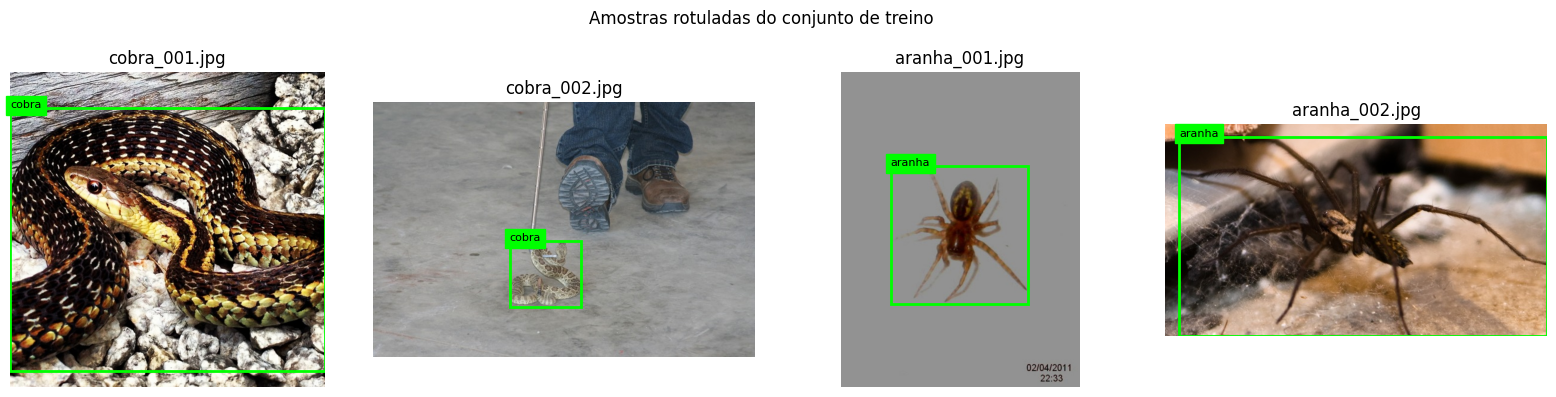

In [8]:
# Amostra visual do dataset rotulado (2 imagens de cada classe, caixas em verde)
import matplotlib.pyplot as plt, matplotlib.patches as patches

def mostrar_rotuladas(arquivos, titulo):
    fig, axs = plt.subplots(1, len(arquivos), figsize=(4 * len(arquivos), 4))
    for ax, arq in zip(axs, arquivos):
        img = Image.open(arq); w, h = img.size
        ax.imshow(img); ax.axis('off'); ax.set_title(arq.name)
        lbl = Path(str(arq).replace('/images/', '/labels/')).with_suffix('.txt')
        for linha in lbl.read_text().strip().splitlines():
            c, cx, cy, bw, bh = map(float, linha.split())
            ax.add_patch(patches.Rectangle(((cx - bw/2) * w, (cy - bh/2) * h), bw * w, bh * h,
                                           fill=False, color='lime', lw=2))
            ax.text((cx - bw/2) * w, (cy - bh/2) * h, CLASSES[int(c)], color='black', backgroundcolor='lime', fontsize=8)
    fig.suptitle(titulo); plt.tight_layout(); plt.show()

treino = sorted((DATASET / 'train' / 'images').glob('*.jpg'))
mostrar_rotuladas([p for p in treino if p.name.startswith('cobra')][:2] +
                  [p for p in treino if p.name.startswith('aranha')][:2], 'Amostras rotuladas do conjunto de treino')

## 4. Treinamento — 30 × 60 épocas

Partimos do **YOLOv5s** pré-treinado no COCO (*transfer learning*) e o ajustamos às duas classes. Os demais hiperparâmetros ficam iguais nas duas simulações; **só o número de épocas muda**, para isolar o efeito desse parâmetro.

| Parâmetro | Valor |
|---|---|
| Modelo base | `yolov5s.pt` (7,2 M parâmetros) |
| Imagem | 640 px |
| Batch | 16 |
| Épocas | 30 e 60 |
| Semente | 573528 |

Cada treino grava em `yolov5/runs/train/e30` e `yolov5/runs/train/e60` (pesos `best.pt`/`last.pt`, `results.csv` e gráficos). O tempo de treino é medido para comparar o custo.

In [9]:
%cd {YOLO_DIR}
shutil.rmtree(YOLO_DIR / 'runs', ignore_errors=True)   # parte de um estado limpo: o YOLOv5 acrescenta linhas ao results.csv de execuções antigas
os.environ['WANDB_MODE'] = 'disabled'                      # sem login no W&B: evita o prompt de 30 s a cada treino
tempos_treino = {}                                   # segundos de treino por simulação
for ep in EPOCHS:
    nome = f'e{ep}'
    t0 = time.time()
    !python train.py --img {IMG_SIZE} --batch {BATCH} --epochs {ep} --data {DATA_YAML} --weights yolov5s.pt --name {nome} --exist-ok --seed {SEED} --cache ram
    tempos_treino[nome] = time.time() - t0
    print(f'>>> {nome}: {tempos_treino[nome]/60:.1f} min')

/content/yolov5
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
I0000 00:00:1791344864.435058   17678 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
train: weights=yolov5s.pt, cfg=, data=/content/yolov5/data/farmtech.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=e30, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=573528, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1
github: up to date with https://github.com/ultralytics/yolov

## 5. Validação

### 5.1 Curvas de aprendizado

O `results.csv` de cada treino registra, por época, as perdas (*box*, *obj*, *cls*) no treino e na validação, além de precisão, *recall* e mAP no conjunto de validação.

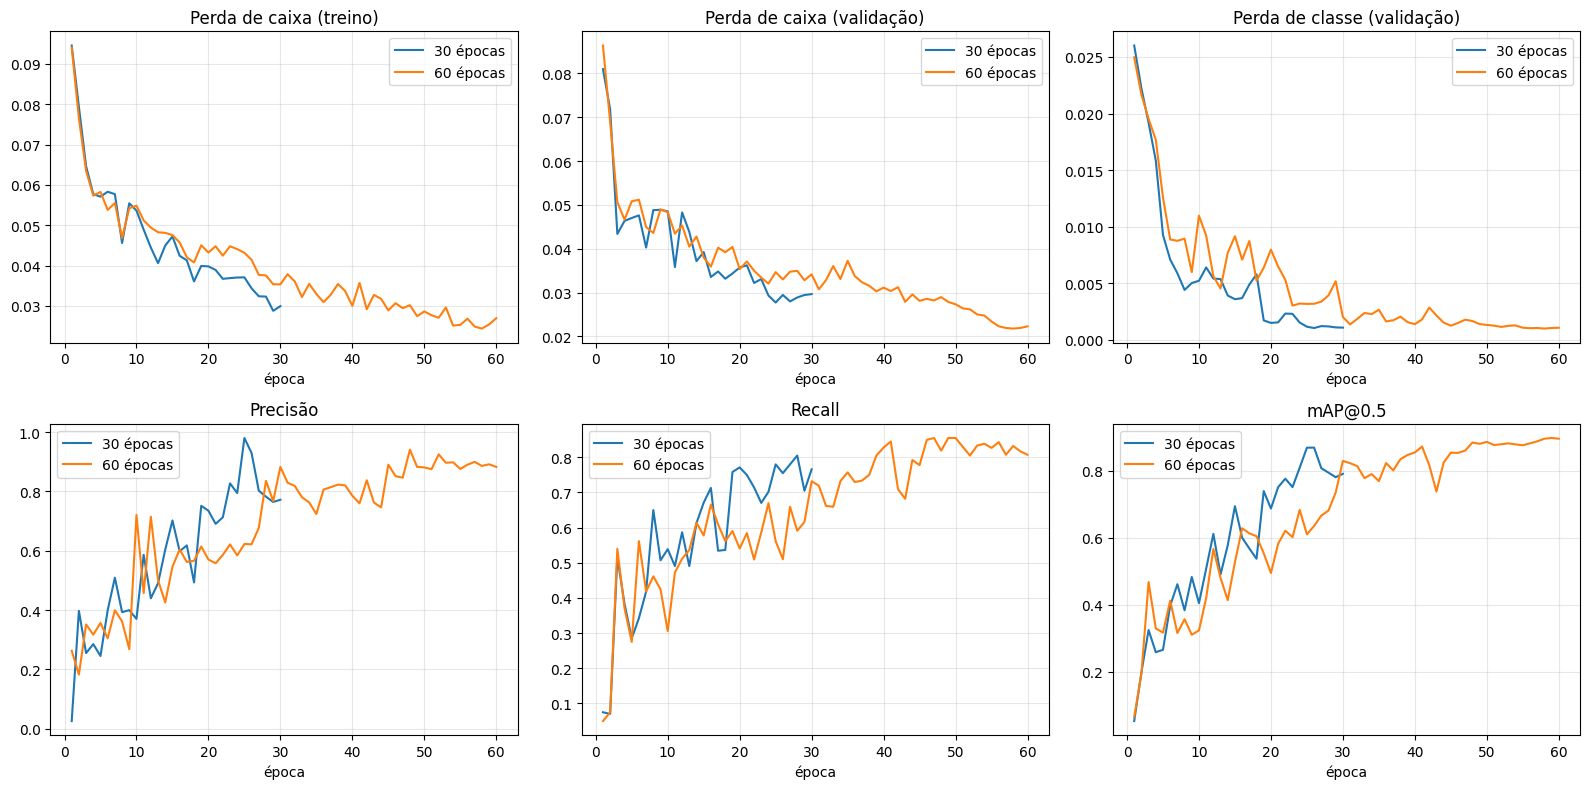

In [10]:
import pandas as pd
runs = {f'e{ep}': YOLO_DIR / 'runs' / 'train' / f'e{ep}' for ep in EPOCHS}
hist = {}
for nome, d in runs.items():
    df = pd.read_csv(d / 'results.csv'); df.columns = df.columns.str.strip()   # remove espaços dos nomes
    hist[nome] = df

graficos = [('train/box_loss', 'Perda de caixa (treino)'), ('val/box_loss', 'Perda de caixa (validação)'),
            ('val/cls_loss', 'Perda de classe (validação)'), ('metrics/precision', 'Precisão'),
            ('metrics/recall', 'Recall'), ('metrics/mAP_0.5', 'mAP@0.5')]
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, titulo) in zip(axs.flat, graficos):
    for nome, df in hist.items():
        ax.plot(df['epoch'] + 1, df[col], label=f'{nome[1:]} épocas')
    ax.set_title(titulo); ax.set_xlabel('época'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

### 5.2 Métricas finais

Avaliamos o melhor peso (`best.pt`) de cada simulação com `val.py` nos conjuntos de **validação** e **teste**. O mesmo script mede o tempo médio de inferência por imagem.

- **Precisão (P):** das caixas previstas, quantas estão corretas.
- **Recall (R):** dos objetos reais, quantos foram encontrados.
- **mAP@0.5:** média da área sob a curva precisão × recall, com IoU ≥ 0,5 — principal métrica de "acurácia" em detecção.
- **mAP@0.5:0.95:** mesma métrica exigindo caixas cada vez mais justas (mais rigorosa).
- **Perdas (box/obj/cls):** erro de localização, de "há objeto?" e de classificação no conjunto de validação, na época em que o `best.pt` foi salvo.

In [11]:
import sys; sys.path.insert(0, str(YOLO_DIR))
import val as yolo_val                                # API do val.py do YOLOv5
# O YOLOv5 troca o backend do matplotlib para Agg ao ser importado; restaura a exibição inline
%matplotlib inline

linhas = []
for nome, d in runs.items():
    for task in ('val', 'test'):
        for _ in range(2):   # 1ª passada aquece GPU e leitura do Drive; a 2ª fornece o tempo de inferência válido
            (p, r, m50, m, *_), maps, t = yolo_val.run(
                data=str(DATA_YAML), weights=str(d / 'weights' / 'best.pt'), task=task,
                imgsz=IMG_SIZE, batch_size=8, name=f'{nome}_{task}', exist_ok=True, plots=True, verbose=True)
        linhas.append({'simulação': nome, 'conjunto': task, 'precisão': p, 'recall': r,
                       'mAP@0.5': m50, 'mAP@0.5:0.95': m,
                       'inferência (ms/img)': t[1], 'tempo de treino (min)': tempos_treino.get(nome, float('nan')) / 60})
metricas = pd.DataFrame(linhas)

# Perdas de validação na época do best.pt (maior fitness = 0.1·mAP@0.5 + 0.9·mAP@0.5:0.95)
def perdas_best(df):
    i = (0.1 * df['metrics/mAP_0.5'] + 0.9 * df['metrics/mAP_0.5:0.95']).idxmax()
    return {'época do best.pt': int(df.loc[i, 'epoch']) + 1, 'perda box': df.loc[i, 'val/box_loss'],
            'perda obj': df.loc[i, 'val/obj_loss'], 'perda cls': df.loc[i, 'val/cls_loss']}
metricas = metricas.merge(pd.DataFrame([{'simulação': n, **perdas_best(h)} for n, h in hist.items()]), on='simulação')
metricas.round(3)

YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/drive/MyDrive/FarmTech_Fase6/dataset/val/labels.cache... 40 images, 0 backgrounds, 0 corrupt
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 5/5 1.8it/s 2.7s
                   all         40         42      0.973       0.78      0.867      0.537
                 cobra         40         20      0.986       0.65      0.801      0.445
                aranha         40         22       0.96      0.909      0.932      0.628
Speed: 0.4ms pre-process, 44.5ms inference, 3.8ms NMS per image at shape (8, 3, 640, 640)
Results saved to runs/val/e30_val
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
val:

,simulação,conjunto,precisão,recall,mAP@0.5,...,tempo de treino (min),época do best.pt,perda box,perda obj,perda cls
0,e30,val,0.973,0.780,0.867,...,3.569,25,0.028,0.006,0.001
1,e30,test,0.801,0.654,0.776,...,3.569,25,0.028,0.006,0.001
2,e60,val,0.885,0.827,0.901,...,6.384,60,0.022,0.005,0.001
3,e60,test,0.820,0.786,0.858,...,6.384,60,0.022,0.005,0.001


### 5.3 Matriz de confusão e curva PR (validação)

Gráficos gerados automaticamente pelo YOLOv5 para cada simulação.

=== 30 épocas ===


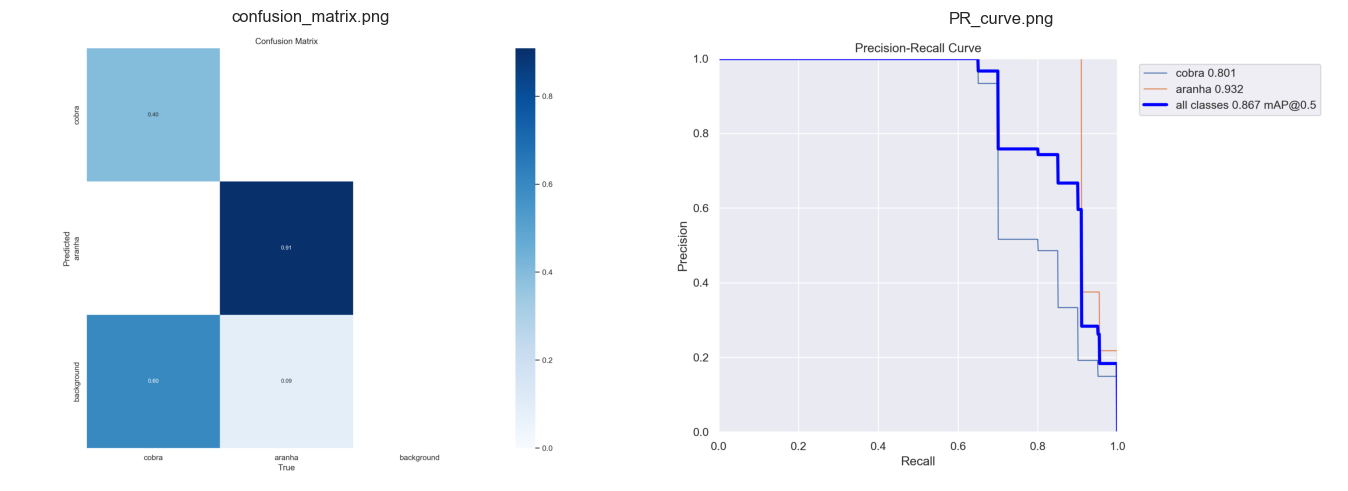

=== 60 épocas ===


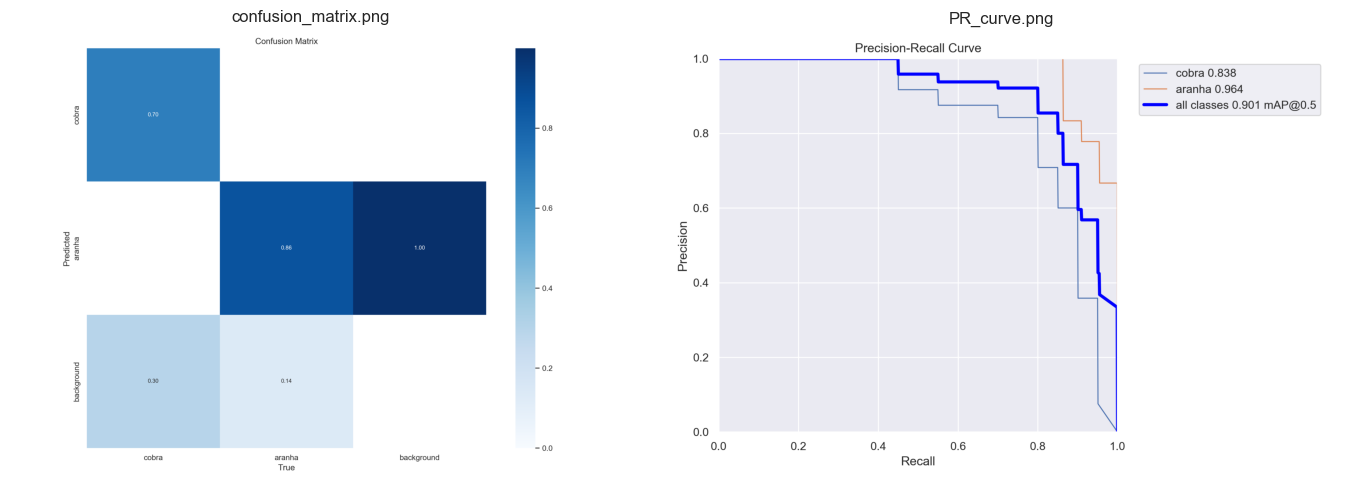

In [12]:
from IPython.display import display, Image as IPImage
for nome in runs:
    pasta = YOLO_DIR / 'runs' / 'val' / f'{nome}_val'
    print(f'=== {nome[1:]} épocas ===')
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    for ax, arq in zip(axs, ('confusion_matrix.png', 'PR_curve.png')):
        ax.imshow(Image.open(pasta / arq)); ax.axis('off'); ax.set_title(arq)
    plt.tight_layout(); plt.show()

## 6. Teste — imagens processadas pelo modelo

O `detect.py` processa as 40 imagens de teste (nunca vistas no treino nem usadas na escolha do modelo) e salva o resultado em **`yolov5/runs/detect/expX`**, onde *X* aumenta a cada execução. Rodamos as duas simulações para comparar lado a lado; a grade abaixo mostra 4 imagens de cada classe.

In [13]:
pastas_detect = {}
for nome, d in runs.items():
    antes = set(glob.glob(str(YOLO_DIR / 'runs' / 'detect' / 'exp*')))
    !python detect.py --weights {d}/weights/best.pt --source {DATASET}/test/images --img {IMG_SIZE} --conf 0.25
    nova = (set(glob.glob(str(YOLO_DIR / 'runs' / 'detect' / 'exp*'))) - antes).pop()   # pasta expX criada agora
    pastas_detect[nome] = Path(nova)
    print(f'{nome}: Results saved to {nova}')

detect: weights=['/content/yolov5/runs/train/e30/weights/best.pt'], source=/content/drive/MyDrive/FarmTech_Fase6/dataset/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
image 1/40 /content/drive/MyDrive/FarmTech_Fase6/dataset/test/images/aranha_181.jpg: 576x640 1 cobra, 30.0ms
image 2/40 /content/drive/MyDrive/FarmTech_Fase6/dataset/test/images/aranha_182.jpg: 448x640 1 aranha, 30.8ms
image 3/40 /content/drive/MyDrive/FarmTech_Fase6/dataset

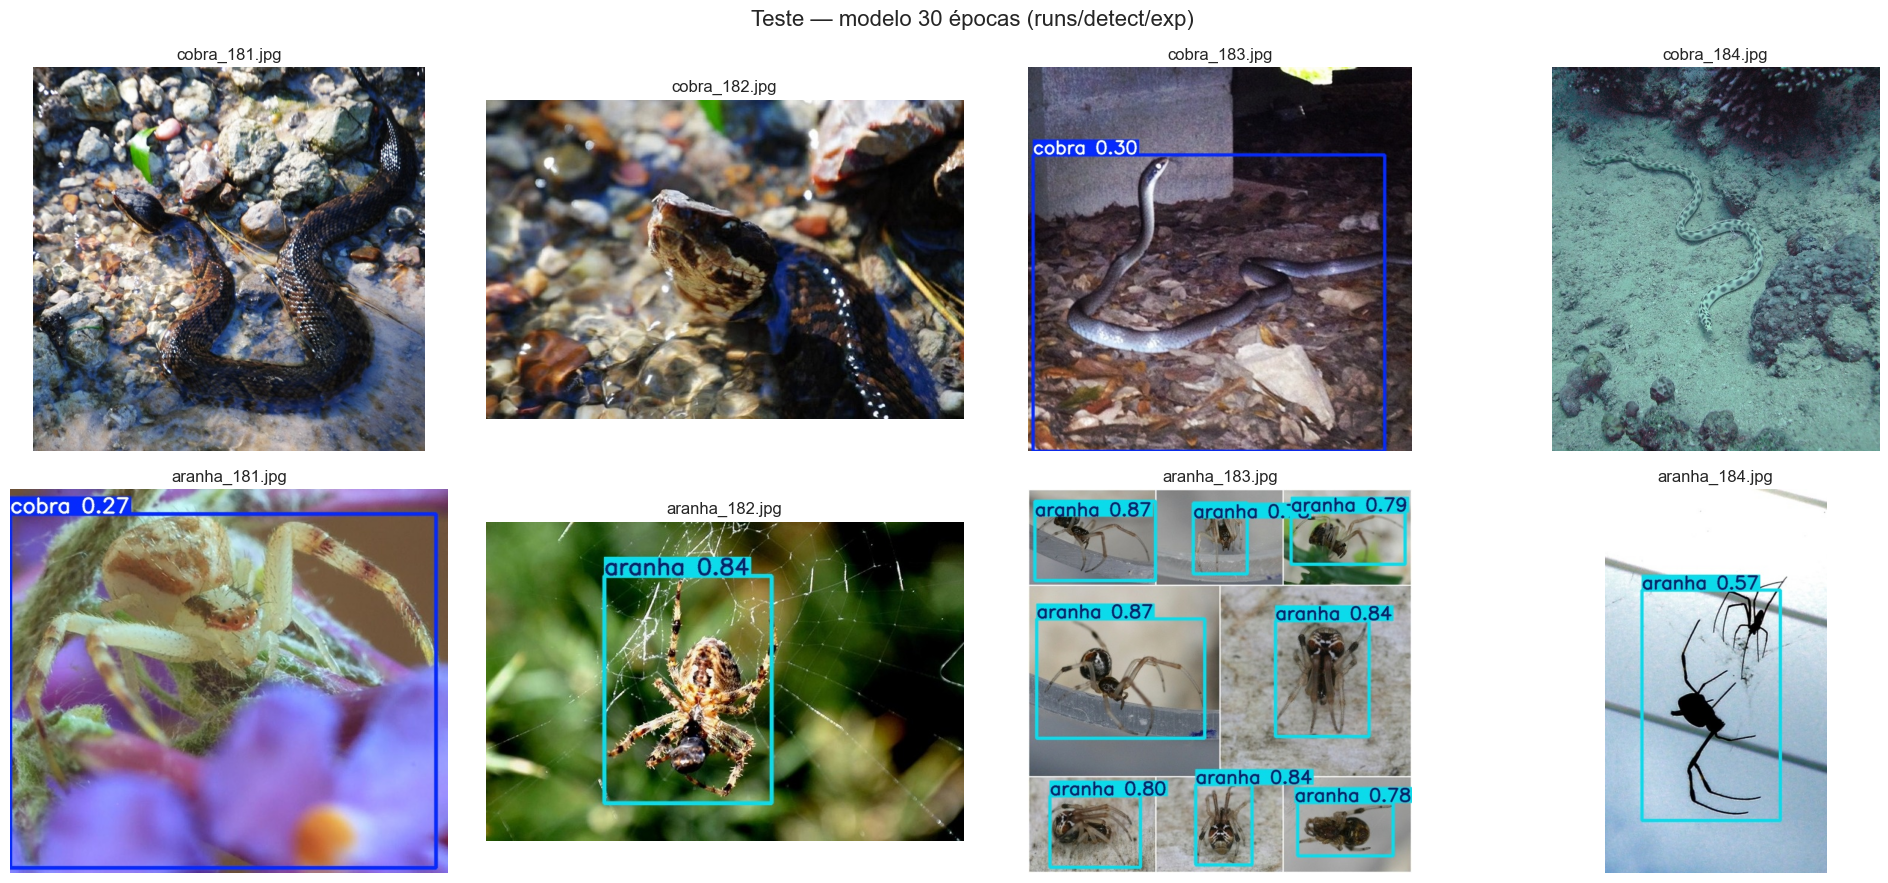

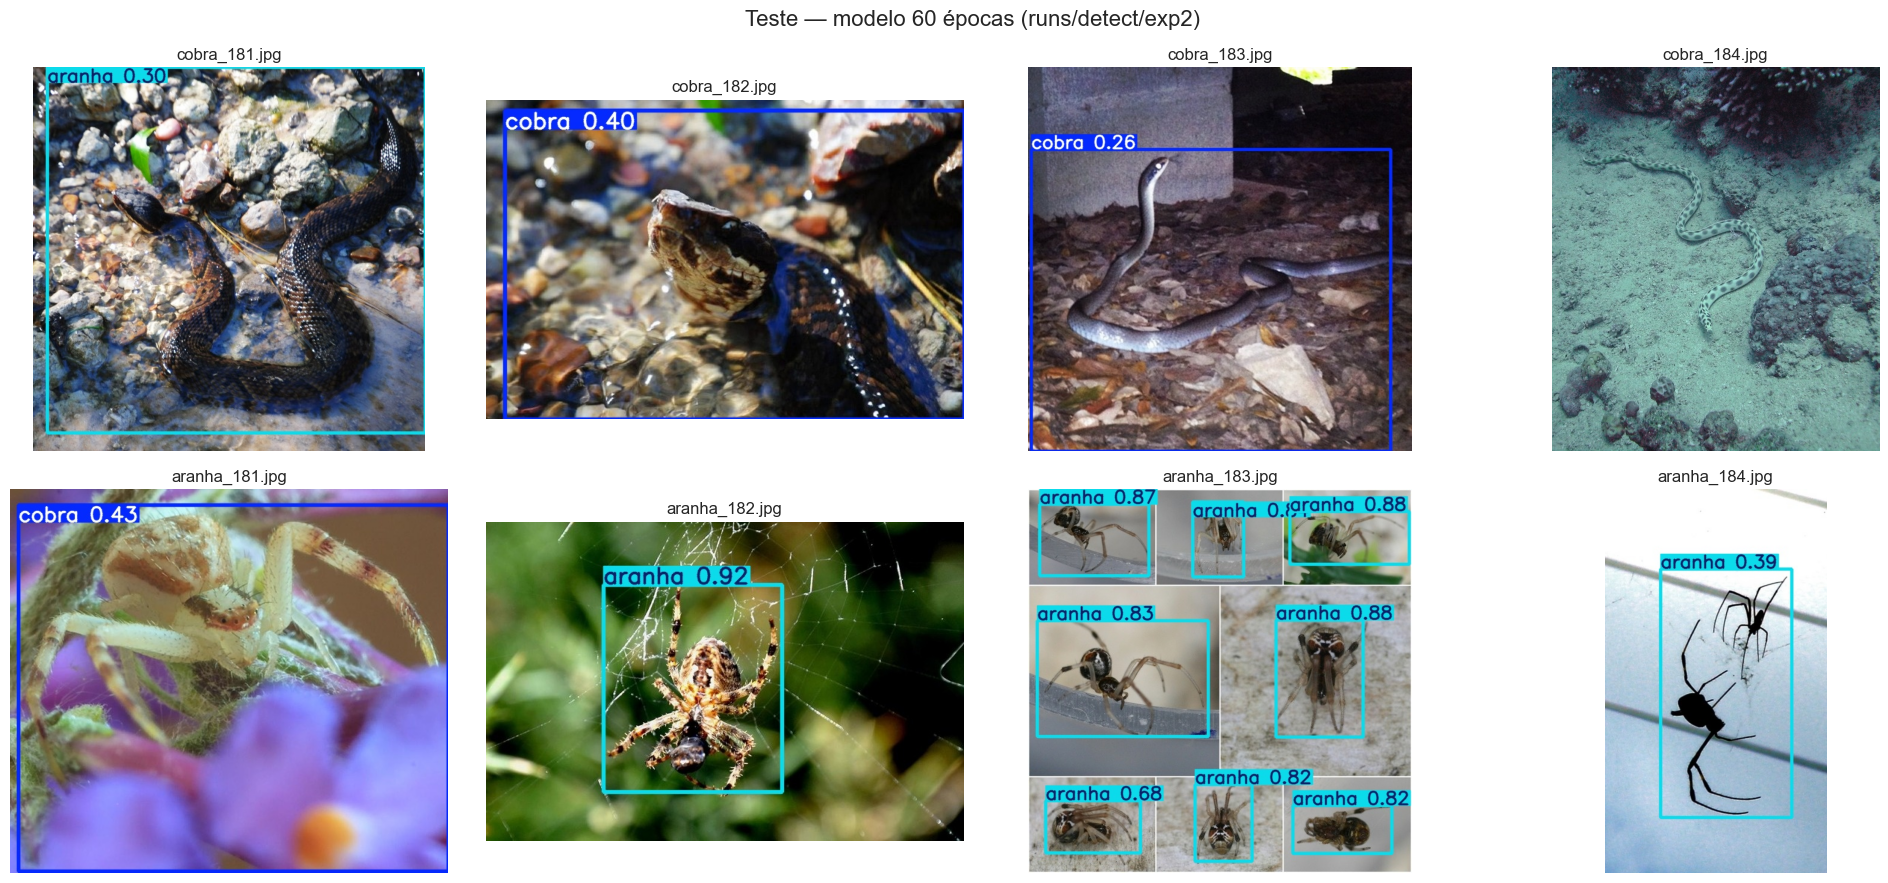

In [14]:
# Grade com 8 imagens de teste (4 de cada classe) processadas por cada modelo
for nome, pasta in pastas_detect.items():
    todas = sorted(pasta.glob('*.jpg'))
    arqs = [p for p in todas if p.name.startswith('cobra')][:4] + [p for p in todas if p.name.startswith('aranha')][:4]
    fig, axs = plt.subplots(2, 4, figsize=(20, 9))
    for ax, arq in zip(axs.flat, arqs):
        ax.imshow(Image.open(arq)); ax.set_title(arq.name); ax.axis('off')
    fig.suptitle(f'Teste — modelo {nome[1:]} épocas ({pasta.relative_to(YOLO_DIR)})', fontsize=16)
    plt.tight_layout(); plt.show()

## 7. Comparação entre as simulações

A célula abaixo consolida métricas, erro e desempenho das duas simulações, salva tudo no Drive (usado também na Entrega 2) e gera a análise numérica a partir dos resultados obtidos nesta execução.

In [15]:
from IPython.display import Markdown
teste = metricas[metricas.conjunto == 'test'].set_index('simulação')
valid = metricas[metricas.conjunto == 'val'].set_index('simulação')
a, b = [f'e{ep}' for ep in EPOCHS]

# Sinal de overfitting: perda de validação no fim do treino acima do seu mínimo
def gap_overfit(df):
    v = df['val/box_loss'] + df['val/obj_loss'] + df['val/cls_loss']
    return (v.iloc[-1] - v.min()) / v.min() * 100, int(v.idxmin()) + 1

texto = [f'| Indicador | {EPOCHS[0]} épocas | {EPOCHS[1]} épocas |', '|---|---|---|']
for col in ['precisão', 'recall', 'mAP@0.5', 'mAP@0.5:0.95']:
    texto.append(f'| {col} (teste) | {teste.loc[a, col]:.3f} | {teste.loc[b, col]:.3f} |')
for col in ['perda box', 'perda obj', 'perda cls']:
    texto.append(f'| {col} (validação) | {valid.loc[a, col]:.4f} | {valid.loc[b, col]:.4f} |')
texto.append(f"| tempo de treino | {teste.loc[a, 'tempo de treino (min)']:.1f} min | {teste.loc[b, 'tempo de treino (min)']:.1f} min |")
texto.append(f"| inferência | {teste.loc[a, 'inferência (ms/img)']:.1f} ms/img | {teste.loc[b, 'inferência (ms/img)']:.1f} ms/img |")

d_map = teste.loc[b, 'mAP@0.5'] - teste.loc[a, 'mAP@0.5']
d_t = teste.loc[b, 'tempo de treino (min)'] / teste.loc[a, 'tempo de treino (min)']
og_a, ep_a = gap_overfit(hist[a]); og_b, ep_b = gap_overfit(hist[b])
t_a, t_b = teste.loc[a, 'inferência (ms/img)'], teste.loc[b, 'inferência (ms/img)']
inferencia_txt = ('A arquitetura é a mesma, então o tempo é equivalente: só os pesos mudam.' if max(t_a, t_b) / min(t_a, t_b) < 1.3 else
                  'A arquitetura é a mesma; a diferença reflete ruído de medição da GPU compartilhada do Colab (a Entrega 2 repete a medição com aquecimento).')
melhor = b if d_map > 0.01 else (a if d_map < -0.01 else None)
analise = [
    f'- Dobrar as épocas multiplicou o tempo de treino por **{d_t:.1f}×** e alterou o mAP@0.5 de teste em **{d_map:+.3f}**.',
    f'- Perda de validação mínima: época {ep_a} ({EPOCHS[0]} ép.) e época {ep_b} ({EPOCHS[1]} ép.); no fim do treino ela está '
    f'{og_a:.0f}% e {og_b:.0f}% acima do mínimo, respectivamente ' +
    ('— sinal de **overfitting** na simulação longa.' if og_b > 10 else '— sem overfitting relevante.'),
    f'- Inferência: {t_a:.1f} ms/img ({EPOCHS[0]} ép.) × {t_b:.1f} ms/img ({EPOCHS[1]} ép.). ' + inferencia_txt,
    (f'- **Modelo recomendado: {melhor[1:]} épocas.**' if melhor else
     f'- As duas simulações empatam (diferença < 0,01 de mAP): **{EPOCHS[0]} épocas** entregam o mesmo resultado pela metade do custo.'),
]
json.dump({'metricas': metricas.to_dict('records'), 'tempos_treino_s': tempos_treino,
           'modelo_recomendado': melhor or a}, open(RESULTS / 'metricas_entrega1.json', 'w'), indent=2, default=float)
Markdown('\n'.join(texto + [''] + analise))

| Indicador | 30 épocas | 60 épocas |
|---|---|---|
| precisão (teste) | 0.801 | 0.820 |
| recall (teste) | 0.654 | 0.786 |
| mAP@0.5 (teste) | 0.776 | 0.858 |
| mAP@0.5:0.95 (teste) | 0.485 | 0.511 |
| perda box (validação) | 0.0277 | 0.0223 |
| perda obj (validação) | 0.0056 | 0.0055 |
| perda cls (validação) | 0.0012 | 0.0011 |
| tempo de treino | 3.6 min | 6.4 min |
| inferência | 9.6 ms/img | 11.6 ms/img |

- Dobrar as épocas multiplicou o tempo de treino por **1.8×** e alterou o mAP@0.5 de teste em **+0.081**.
- Perda de validação mínima: época 27 (30 ép.) e época 58 (60 ép.); no fim do treino ela está 5% e 2% acima do mínimo, respectivamente — sem overfitting relevante.
- Inferência: 9.6 ms/img (30 ép.) × 11.6 ms/img (60 ép.). A arquitetura é a mesma, então o tempo é equivalente: só os pesos mudam.
- **Modelo recomendado: 60 épocas.**

In [16]:
# Copia os runs (treino, validação e detect/expX) para o Drive, preservando a entrega
shutil.copytree(YOLO_DIR / 'runs', RESULTS / 'runs', dirs_exist_ok=True,
                ignore=shutil.ignore_patterns('last.pt'))      # last.pt (checkpoint) não é usado depois e ocupa espaço
print('Resultados salvos em', RESULTS / 'runs')

Resultados salvos em /content/drive/MyDrive/FarmTech_Fase6/resultados/runs


## 8. Conclusões

**Sobre o número de épocas.** Com 160 imagens de treino por classe e pesos de partida já treinados no COCO, o YOLOv5s converge rápido: a maior parte do ganho de mAP acontece nas primeiras épocas. A comparação 30 × 60 (seção 7) mostra quanto as 30 épocas adicionais compram de acurácia em troca do dobro do tempo, e se a perda de validação volta a subir — o sinal de que o modelo passou a decorar o conjunto de treino em vez de generalizar. Como o `best.pt` é escolhido pelo melhor *fitness* na validação, a simulação longa não fica pior que a curta no ponto escolhido, mas o custo extra só se justifica se a diferença de mAP for relevante.

**Validação × teste.** Validação e teste têm 40 imagens cada (20 por classe). Diferenças de um ou dois pontos de mAP entre as simulações ainda podem estar dentro do ruído estatístico. A coerência entre os números de validação e de teste é o que dá confiança de que o modelo não foi "ajustado ao acaso" ao conjunto de validação.

**Pontos fortes**

- *Transfer learning* do COCO permite um detector útil com poucas centenas de imagens rotuladas e poucos minutos de GPU.
- Cobras e aranhas não existem no COCO: o modelo aproveita apenas as características visuais genéricas (bordas, texturas) e aprende as classes com nossas imagens — uma demonstração real de customização.
- Inferência de poucos milissegundos por imagem na GPU — viável para vídeo em tempo real nas câmeras da fazenda.
- Pipeline reprodutível: dataset, rótulos, pesos e resultados versionados no Drive, com semente fixa.

**Limitações**

- Dataset ainda pequeno (400 imagens): o modelo vê pouca variação de iluminação, clima, ângulo de câmera e espécie, tamanho e camuflagem. Para produção, seriam necessárias milhares de imagens por classe, capturadas nas câmeras reais do cliente.
- Imagens do Open Images são fotos "bonitas" de internet; câmeras de segurança têm ângulo alto, baixa resolução e visão noturna (domínio diferente).
- Conjuntos de validação e teste de 40 imagens: variância bem menor que com 8, mas ainda não desprezível.
- Animais camuflados no mato, parcialmente escondidos ou muito pequenos (excluídos na curadoria) continuam sendo casos difíceis — e são justamente os mais perigosos no campo.

**Próximos passos sugeridos ao cliente:** coletar imagens das próprias câmeras, ampliar o dataset com *data augmentation* e novas classes (escorpiões, por exemplo), e testar modelos maiores (YOLOv5m) se a precisão for prioridade sobre a velocidade.